<a href="https://colab.research.google.com/github/anuhingankar9922-hub/-Python-Basic-Projects/blob/main/Task17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Load the Heart Disease dataset using pandas and display the first 10 rows. Also check the shape and basic information (info()) of the dataset.

In [12]:
import pandas as pd

df = pd.read_csv("heart.csv")

print("<><><><><><><><><><><><><><><><> First 10 Rows <><><><><><><><><><><><><><><><>\n")
print(df.head(10))
print()
print("\n<> Shape of Dataset <>\n")
print(df.shape)
print()
print("\n<><><><><><><><><> Dataset Information <><><><><><><><>\n")
print(df.info())

<><><><><><><><><><><><><><><><> First 10 Rows <><><><><><><><><><><><><><><><>

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak S

Q2. Check for missing values in the dataset. Show the count of null values for each column.

In [16]:
print("-> Missing Values in Each Column <-\n")
print(df.isnull().sum())

-> Missing Values in Each Column <-

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Q3. Check for duplicate rows in the dataset. If any duplicates are found, remove them and print the new shape of the dataset.

In [20]:
print("-> Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("\n-> New Shape of Dataset:", df.shape)

-> Duplicate Rows: 0

-> New Shape of Dataset: (918, 12)


Q4. Identify unrealistic/invalid values: Count how many rows have Cholesterol = 0. Count how many rows have RestingBP  0. Print both counts.

In [38]:
print("Rows having Cholesterol = 0:", (df["Cholesterol"] == 0).sum())
print("\nRows having RestingBP = 0:", (df["RestingBP"] == 0).sum())

Rows having Cholesterol = 0: 172

Rows having RestingBP = 0: 1


Q5. Clean the invalid values: Replace Cholesterol = 0 with the mean cholesterol value (excluding zeros). Replace RestingBP  0 with the mean resting blood pressure value (excluding zeros). Round both columns to 2 decimal places. Print the statistical summary (describe()) of these two columns before and after cleaning.

In [61]:
print("________Before Cleaning________\n")
print(df[["Cholesterol", "RestingBP"]].describe())

chol = df[df["Cholesterol"] != 0]
chol_mean = chol["Cholesterol"].mean()
df["Cholesterol"] = df["Cholesterol"].replace(0, 244.63)

bp = df[df["RestingBP"] != 0]
bp_mean = bp["RestingBP"].mean()
df["RestingBP"] = df["RestingBP"].replace(0, 132.40)

df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("\n________After Cleaning________\n")
print(df[["Cholesterol", "RestingBP"]].describe())

________Before Cleaning________

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.634379  132.540741
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.630000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

________After Cleaning________

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.634379  132.540741
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.630000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


Q6. Create a function to plot histograms for the following numerical columns: Age RestingBP Cholesterol MaxHR Plot all four histograms in one figure using subplots (2x2 layout). Use this function to visualize the data after cleaning.

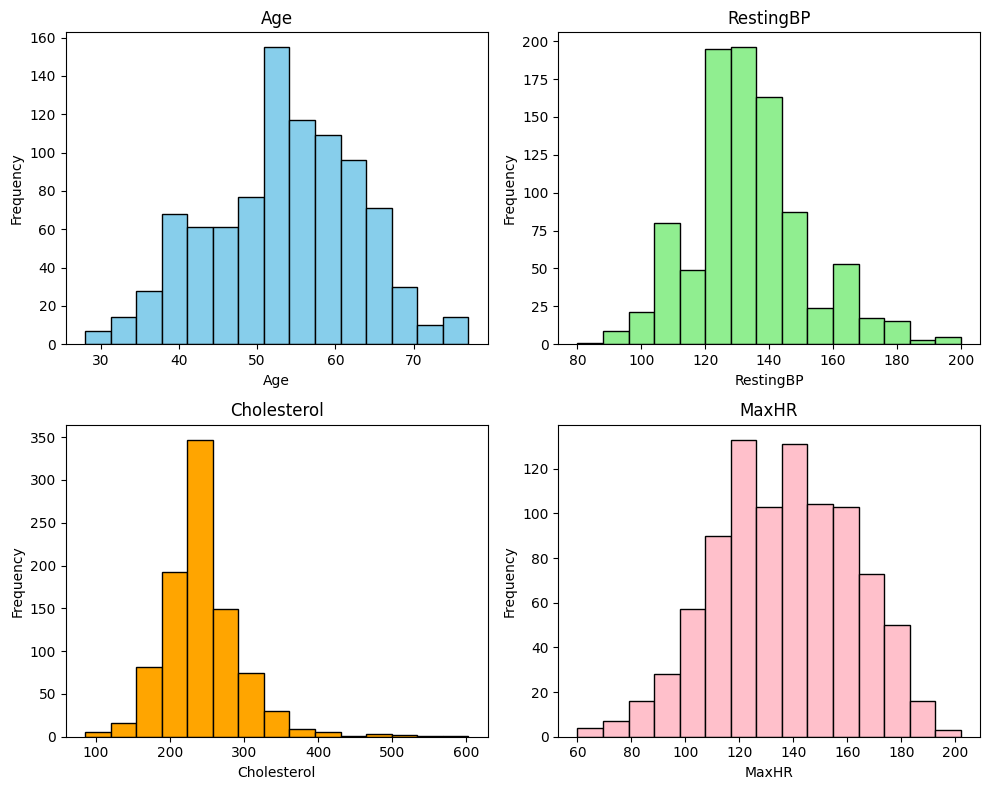

In [69]:
import matplotlib.pyplot as plt

def plot_hist(column, color):
    plt.hist(df[column], bins=15, color=color, edgecolor="black")
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plot_hist("Age", "skyblue")

plt.subplot(2, 2, 2)
plot_hist("RestingBP", "lightgreen")

plt.subplot(2, 2, 3)
plot_hist("Cholesterol", "orange")

plt.subplot(2, 2, 4)
plot_hist("MaxHR", "pink")

plt.tight_layout()
plt.show()

Q7. Identify and print numerical columns and categorical columns separately.

In [79]:
numerical = df.select_dtypes(include=["int64", "float64"]).columns
print("--------------------------->Numerical Columns<---------------------------")
print(numerical)

categorical=df.select_dtypes(include=["object"]).columns
print("\n----------------------------------->Categorical Columns<-----------------------------------")
print(categorical)

--------------------------->Numerical Columns<---------------------------
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

----------------------------------->Categorical Columns<-----------------------------------
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


Q8. Perform One-Hot Encoding on all categorical columns using pd.get_dummies(). Store the result in a new dataframe called df_encoded. Print the shape and the first 5 rows of the encoded dataframe.

In [92]:
encoded_data = pd.get_dummies(df)

print("---*Shape of Encoded DataFrame*---")
print(encoded_data.shape)
print()
print("\n**><><_________><><><_________><__First 5 Rows__><_________><><><_________><><**\n")
print(encoded_data.head())

---*Shape of Encoded DataFrame*---
(918, 21)


**><><_________><><><_________><__First 5 Rows__><_________><><><_________><><**

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True     

Q9. After cleaning and encoding: Print the final shape of df_encoded. Show the list of all column names in the final dataframe.

In [101]:
print("Final Shape:-")
print(encoded_data.shape)

print("\nColumn Names:-")
print(encoded_data.columns.tolist())

Final Shape:-
(918, 21)

Column Names:-
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


Q10. (Summary) Write a short summary (in comments or markdown) covering: What invalid values did you find and how did you fix them? , Why is it important to handle invalid values like Cholesterol = 0? , What is the purpose of One-Hot Encoding? , Any other observations from the cleaning process.

In [ ]:
"""
------Summary------
Q.1--->
We found the values that were 0 in the Cholesterol and RestingBP columns.
Then, we replaced those 0 values with the mean of the respective column (excluding zeros) and improved the quality of the dataset.

Q.2--->
It is important to handle invalid values like Cholesterol = 0 because a cholesterol level of 0 is not realistic.
Such invalid values can lead to incorrect analysis and reduce the accuracy of machine learning models.

Q.3--->
One-Hot Encoding converts categorical (text) data into numerical (0 and 1) binary columns so that machine learning algorithms can process it.

Q.4--->
After cleaning, the dataset became more accurate, consistent, and ready for analysis and machine learning.